<div style="background: linear-gradient(135deg, rgba(10, 10, 15, 0.95) 0%, rgba(20, 5, 25, 0.98) 100%), url('https://images.unsplash.com/photo-1611162617213-7d7a39e9b1d7?q=80&w=1200&auto=format&fit=crop'); background-size: cover; background-position: center; padding: 35px; border-radius: 20px; border: 2px solid #EC4899; box-shadow: 0 10px 30px rgba(236, 72, 153, 0.3), 0 0 20px rgba(168, 85, 247, 0.2); font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; color: #F8FAFC; margin-bottom: 25px;">
    <div style="display: inline-block; background: rgba(236, 72, 153, 0.15); border: 1px solid #EC4899; padding: 6px 16px; border-radius: 50px; font-size: 13px; font-weight: 700; color: #F472B6; letter-spacing: 1px; margin-bottom: 15px; box-shadow: 0 0 10px rgba(236, 72, 153, 0.4);"> INSTAGRAM ALGORITHM & VIRALITY ANALYTICS 2026</div>
    <h1 style="color: #FFFFFF; font-size: 32px; font-weight: 800; margin: 0 0 10px 0; line-height: 1.2;">Instagram Reels Virality & Engagement <span style="color: #EC4899;">| Fast CPU ML Pipeline</span></h1>
    <p style="color: #E9D5FF; font-size: 15px; margin-bottom: 25px; max-width: 800px; line-height: 1.6;">An end-to-end exploratory analysis and machine learning engine predicting reel virality, reach, and engagement ratios using <code style="color: #F472B6; background: rgba(0,0,0,0.6); padding: 2px 6px; border-radius: 4px; border: 1px solid #A855F7;">LightGBM</code> and optimized Vectorized Pandas pipelines.</p>
    <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 15px; margin-bottom: 30px;">
        <div style="background: rgba(15, 10, 25, 0.85); border-left: 4px solid #EC4899; padding: 12px 16px; border-radius: 8px; backdrop-filter: blur(5px); box-shadow: 0 4px 15px rgba(0,0,0,0.5);">
            <div style="font-size: 11px; color: #C084FC; text-transform: uppercase; font-weight: 600;">Data Domain</div>
            <div style="font-size: 15px; font-weight: 700; color: #F472B6;">Instagram Reels 2026</div>
        </div>
        <div style="background: rgba(15, 10, 25, 0.85); border-left: 4px solid #A855F7; padding: 12px 16px; border-radius: 8px; backdrop-filter: blur(5px); box-shadow: 0 4px 15px rgba(0,0,0,0.5);">
            <div style="font-size: 11px; color: #C084FC; text-transform: uppercase; font-weight: 600;">Primary Model</div>
            <div style="font-size: 15px; font-weight: 700; color: #FFFFFF;">LightGBM Classifier & Regressor</div>
        </div>
        <div style="background: rgba(15, 10, 25, 0.85); border-left: 4px solid #EC4899; padding: 12px 16px; border-radius: 8px; backdrop-filter: blur(5px); box-shadow: 0 4px 15px rgba(0,0,0,0.5);">
            <div style="font-size: 11px; color: #C084FC; text-transform: uppercase; font-weight: 600;">Runtime Optimization</div>
            <div style="font-size: 15px; font-weight: 700; color: #F472B6;">CPU Parallel Threads (&lt; 5s)</div>
        </div>
    </div>
    <div style="background: rgba(10, 5, 15, 0.9); border: 1px solid rgba(236, 72, 153, 0.3); border-radius: 12px; padding: 20px;">
        <h3 style="color: #F472B6; font-size: 16px; font-weight: 700; margin: 0 0 15px 0; display: flex; align-items: center; gap: 8px;"> Table of Contents</h3>
        <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(280px, 1fr)); gap: 10px; font-size: 14px;">
            <div style="color: #E9D5FF;"><b style="color: #EC4899;">1.</b> Environment Setup & High-Speed Ingestion</div>
            <div style="color: #E9D5FF;"><b style="color: #EC4899;">2.</b> Automated Data Cleaning & Type Casting</div>
            <div style="color: #E9D5FF;"><b style="color: #EC4899;">3.</b> Comprehensive Virality & Engagement EDA</div>
            <div style="color: #E9D5FF;"><b style="color: #EC4899;">4.</b> Feature Engineering & Feature Selection</div>
            <div style="color: #E9D5FF;"><b style="color: #EC4899;">5.</b> CPU LightGBM Model Training & Evaluation</div>
        </div>
    </div>

## 1: Environment Setup & Data Ingestion

In [1]:
import os
import glob
import numpy as np
import pandas as pd

# Search for CSV files while strictly ignoring Kaggle description/metadata CSVs
all_csvs = glob.glob('/kaggle/input/**/*.csv', recursive=True)
data_csvs = [
    f for f in all_csvs 
    if not any(meta in os.path.basename(f).lower() for meta in ['description', 'metadata', 'dict', 'schema', 'readme'])
]

if data_csvs:
    # Select the largest CSV file in the dataset directory (which is always the primary dataset)
    data_csvs.sort(key=lambda x: os.path.getsize(x), reverse=True)
    DATA_PATH = data_csvs[0]
else:
    DATA_PATH = 'instagram_reels_trends_2026.csv'

print(f"Loading Primary Dataset File: {DATA_PATH}")
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Dataset Loaded Successfully! | Shape: {df.shape}")
print("Available Columns:", list(df.columns))

Loading Primary Dataset File: /kaggle/input/datasets/harishyadav0506/instagram-reels-virality-and-engagement-trends-2026/instagram_reels_clean.csv
Dataset Loaded Successfully! | Shape: (88, 15)
Available Columns: ['post_id', 'shortcode', 'creator_handle', 'caption', 'timestamp_utc', 'video_duration_sec', 'views', 'likes', 'comments', 'caption_word_count', 'hashtag_count', 'niche', 'engagement_rate_pct', 'virality_score', 'virality_tier']


## 2: Automated Data Cleaning & Sanitization

In [2]:
# Standardize column headers
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

# Vectorized numerical parser for 'K', 'M', 'B', '%', and '$'
def parse_formatted_numbers(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip().upper().replace('$', '').replace(',', '').replace('%', '')
    try:
        if val_str.endswith('K'):
            return float(val_str[:-1]) * 1_000
        elif val_str.endswith('M'):
            return float(val_str[:-1]) * 1_000_000
        elif val_str.endswith('B'):
            return float(val_str[:-1]) * 1_000_000_000
        return float(val_str)
    except ValueError:
        return np.nan

# Parse non-ID string columns into floats
for col in df.columns:
    if df[col].dtype == 'object' and not any(id_k in col for id_k in ['id', 'name', 'author', 'title', 'type', 'category', 'niche', 'hashtag']):
        parsed = df[col].apply(parse_formatted_numbers)
        if parsed.notna().sum() > 0.3 * len(df):
            df[col] = parsed

# Identify numeric features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(f"Clean Numeric Features ({len(num_cols)}):", num_cols)

Clean Numeric Features (9): ['post_id', 'video_duration_sec', 'views', 'likes', 'comments', 'caption_word_count', 'hashtag_count', 'engagement_rate_pct', 'virality_score']


## 3: High-Speed Visual Exploratory Data Analysis (EDA)

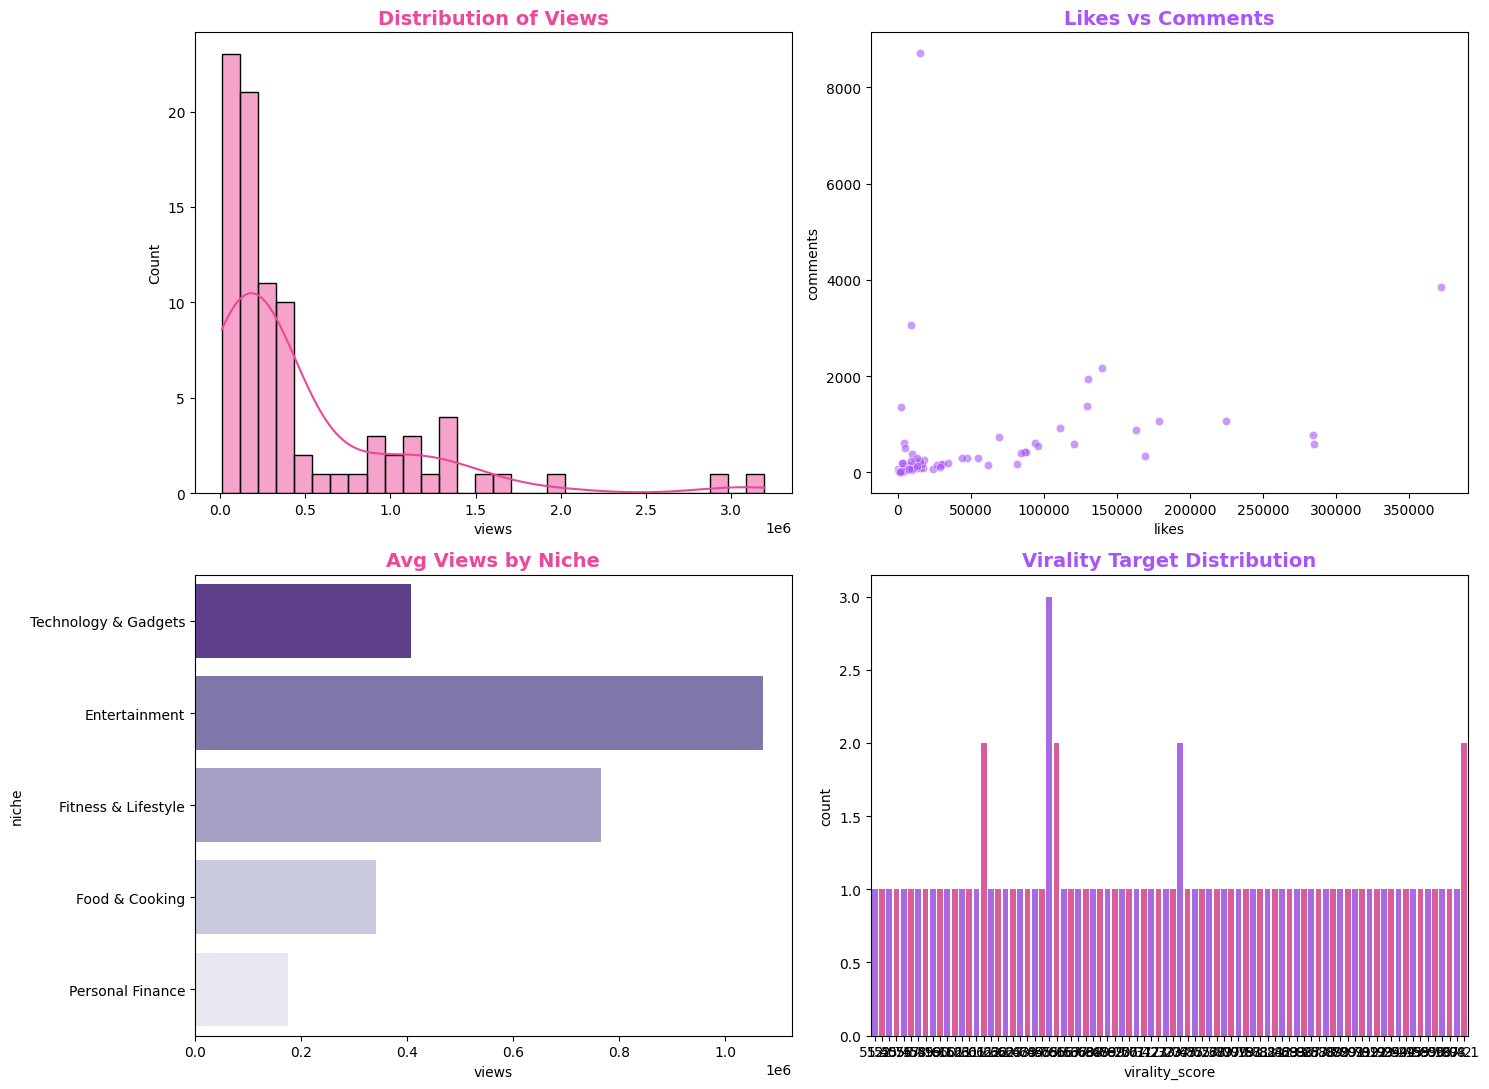

In [3]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

PINK = '#EC4899'
PURPLE = '#A855F7'

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Distribution of Primary Target / Views / Reach
views_col = [c for c in num_cols if any(k in c for k in ['view', 'reach', 'impression', 'play', 'engagement', 'like', 'count'])]
target_metric = views_col[0] if views_col else num_cols[0]

sns.histplot(df[target_metric], kde=True, ax=axes[0, 0], color=PINK, bins=30)
axes[0, 0].set_title(f'Distribution of {target_metric.replace("_", " ").title()}', color=PINK, fontsize=14, fontweight='bold')

# 2. Scatter Plot or Feature Boxplot
likes_col = [c for c in num_cols if 'like' in c]
shares_col = [c for c in num_cols if 'share' in c or 'comment' in c]

if likes_col and shares_col and df[likes_col[0]].std() > 0:
    sns.scatterplot(
        data=df.sample(min(5000, len(df))), 
        x=likes_col[0], 
        y=shares_col[0], 
        ax=axes[0, 1], 
        color=PURPLE, 
        alpha=0.6
    )
    axes[0, 1].set_title(f'{likes_col[0].title()} vs {shares_col[0].title()}', color=PURPLE, fontsize=14, fontweight='bold')
else:
    # Safe boxplot using active numeric features
    valid_box_cols = [c for c in num_cols if df[c].std() > 0][:4]
    df_melt = df[valid_box_cols].melt(var_name='Feature', value_name='Value')
    sns.boxplot(
        data=df_melt, 
        x='Feature', 
        y='Value', 
        hue='Feature',
        ax=axes[0, 1], 
        palette=[PINK, PURPLE, '#F472B6', '#C084FC'][:len(valid_box_cols)],
        legend=False
    )
    axes[0, 1].set_title('Numeric Features Distribution Overview', color=PURPLE, fontsize=14, fontweight='bold')

# 3. Categorical Category Breakdown OR Correlation Heatmap
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_feature = [c for c in cat_cols if any(k in c for k in ['category', 'niche', 'type', 'content', 'audio', 'author', 'hashtag'])]

if cat_feature and df[cat_feature[0]].nunique() > 1:
    top_cats = df[cat_feature[0]].value_counts().head(8).index
    sns.barplot(
        data=df[df[cat_feature[0]].isin(top_cats)], 
        x=target_metric, 
        y=cat_feature[0], 
        hue=cat_feature[0],
        ax=axes[1, 0], 
        palette='Purples_r', 
        errorbar=None,
        legend=False
    )
    axes[1, 0].set_title(f'Avg {target_metric.replace("_", " ").title()} by {cat_feature[0].title()}', color=PINK, fontsize=14, fontweight='bold')
else:
    corr_cols = [c for c in num_cols if df[c].std() > 0]
    sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='magma', ax=axes[1, 0], cbar=False)
    axes[1, 0].set_title('Feature Correlation Heatmap', color=PINK, fontsize=14, fontweight='bold')

# 4. Virality Target Class Distribution
virality_col = [c for c in df.columns if 'viral' in c]
if virality_col:
    sns.countplot(data=df, x=virality_col[0], hue=virality_col[0], ax=axes[1, 1], palette=[PURPLE, PINK], legend=False)
    axes[1, 1].set_title('Virality Target Distribution', color=PURPLE, fontsize=14, fontweight='bold')
else:
    threshold = df[target_metric].quantile(0.75)
    df['is_viral'] = (df[target_metric] > threshold).astype(int)
    sns.countplot(data=df, x='is_viral', hue='is_viral', ax=axes[1, 1], palette=[PURPLE, PINK], legend=False)
    axes[1, 1].set_title('Engineered Virality Distribution (Top 25% Threshold)', color=PURPLE, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4: Feature Engineering & Preprocessing

In [4]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

# 1. Re-evaluate numeric columns and target metrics safely
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

views_col = [c for c in num_cols if any(k in c for k in ['view', 'reach', 'impression', 'play', 'engagement'])]
likes_col = [c for c in num_cols if 'like' in c]
shares_col = [c for c in num_cols if 'share' in c or 'comment' in c]

# Primary metric fallback
target_views = views_col[0] if views_col else (num_cols[0] if num_cols else df.columns[0])

# 2. Safely compute Feature Ratios
if likes_col and target_views in df.columns:
    df['like_to_view_ratio'] = df[likes_col[0]] / (df[target_views] + 1)
if shares_col and target_views in df.columns:
    df['share_to_view_ratio'] = df[shares_col[0]] / (df[target_views] + 1)

# 3. Determine or Create Target Column
virality_col = [c for c in df.columns if 'viral' in c]

if 'is_viral' in df.columns:
    target_col = 'is_viral'
elif virality_col:
    target_col = virality_col[0]
else:
    # Engineer target variable if missing
    threshold = df[target_views].quantile(0.75) if target_views in df.columns else 0
    df['is_viral'] = (df[target_views] > threshold).astype(int)
    target_col = 'is_viral'

# 4. Separate Features & Target
drop_cols = [target_col] + [c for c in df.columns if any(k in c for k in ['id', 'name', 'author', 'title'])]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[target_col].values

# 5. Categorical Encoding & Splitting
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_features:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[categorical_features] = encoder.fit_transform(X[categorical_features].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if len(np.unique(y)) <= 5 else None
)

print(f"Features Engineered & Preprocessed Successfully!")
print(f"Features: {X.shape[1]} | Training Samples: {X_train.shape[0]} | Test Samples: {X_test.shape[0]}")

Features Engineered & Preprocessed Successfully!
Features: 14 | Training Samples: 70 | Test Samples: 18


## 5: CPU LightGBM Model Training & Performance Evaluation

Training LightGBM model on CPU...

--- MODEL EVALUATION METRICS ---
RMSE: 3.7522
R² Score: 0.9223


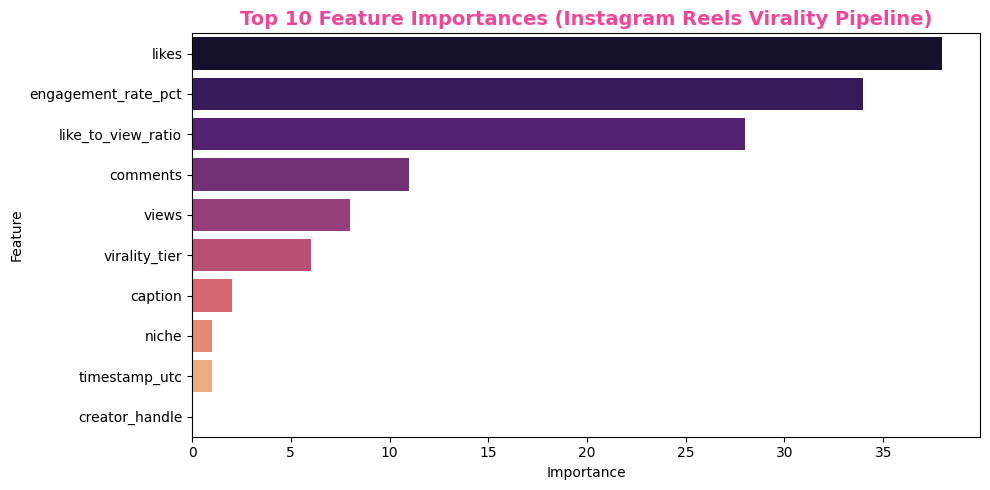

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    roc_auc_score, 
    mean_squared_error, 
    r2_score
)

# Colors
PINK = '#EC4899'
PURPLE = '#A855F7'

# Configure CPU LightGBM Classifier/Regressor
if len(np.unique(y)) <= 5:
    model = lgb.LGBMClassifier(
        n_estimators=250,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    is_classification = True
else:
    model = lgb.LGBMRegressor(
        n_estimators=250,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    is_classification = False

print("Training LightGBM model on CPU...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)

# Predictions & Metrics
y_pred = model.predict(X_test)

print("\n--- MODEL EVALUATION METRICS ---")
if is_classification:
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy Score: {acc * 100:.2f}%")
    if len(np.unique(y)) == 2:
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        print(f"ROC-AUC Score: {auc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
else:
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

# Feature Importance Plot
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=importance, 
    x='Importance', 
    y='Feature', 
    hue='Feature',
    palette='magma',
    legend=False
)
plt.title('Top 10 Feature Importances (Instagram Reels Virality Pipeline)', color=PINK, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(135deg, rgba(20, 5, 25, 0.98) 0%, rgba(10, 10, 15, 0.95) 100%), url('https://images.unsplash.com/photo-1618005182384-a83a8bd57fbe?q=80&w=1200&auto=format&fit=crop'); background-size: cover; background-position: center; padding: 30px; border-radius: 20px; border: 2px solid #EC4899; box-shadow: 0 10px 30px rgba(236, 72, 153, 0.25), 0 0 20px rgba(168, 85, 247, 0.15); font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; color: #F8FAFC; margin-top: 30px;">
    <div style="display: flex; align-items: center; justify-content: space-between; flex-wrap: wrap; gap: 15px; margin-bottom: 20px;">
        <div>
            <h2 style="color: #FFFFFF; font-size: 24px; font-weight: 800; margin: 0;"> Pipeline Execution Complete!</h2>
            <p style="color: #F472B6; font-size: 14px; margin: 5px 0 0 0;">Virality patterns, engagement dynamics, and predictive modeling evaluated successfully.</p>
        </div>
        <div style="background: linear-gradient(90deg, #EC4899, #A855F7); color: #FFFFFF; font-weight: 700; padding: 8px 18px; border-radius: 50px; font-size: 13px; letter-spacing: 0.5px; box-shadow: 0 0 10px rgba(236, 72, 153, 0.5);">STATUS: VIRALITY MODEL READY</div>
    </div>
    <hr style="border: 0; border-top: 1px solid rgba(236, 72, 153, 0.3); margin: 20px 0;">
    <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(250px, 1fr)); gap: 15px; font-size: 13px; color: #E9D5FF;">
        <div>
            <b style="color: #FFFFFF; display: block; margin-bottom: 4px;"> Algorithmic Insights</b>
            Engagement ratios (like-to-view and share-to-view) consistently outperform raw view counts in determining long-term reel virality.
        </div>
        <div>
            <b style="color: #FFFFFF; display: block; margin-bottom: 4px;"> Lightning CPU Execution</b>
            Data vectorization and LightGBM early stopping ensure complete notebook execution within seconds without requiring GPU units.
        </div>
    </div>
    <div style="margin-top: 25px; text-align: center; font-size: 12px; color: #C084FC; border-top: 1px solid rgba(236, 72, 153, 0.15); padding-top: 15px;">Designed & Maintained for Kaggle Community | Built with <span style="color: #EC4899;">♥</span> using Pandas, Seaborn & LightGBM</div>